# Trabalho Prático: Correlação de Astrous

Alunos: Adriel Ferreira & Kamily Assis

Características:
- leitura de parâmetros via json
- validação de parâmetros
- leitura da Imagem
- separação em canais RGB
- aplicação de filtro em correlação dilatada
- comparação com funções prontas


# Funções

## 1. Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import json
import os

## 2. Visualização

In [2]:
def show_image(img, title=None, cmap=None):
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap=cmap)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

In [3]:
def exibir_canais_rgb(r_color, g_color, b_color, rgb_array):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 4, 1)
    plt.imshow(rgb_array)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(r_color)
    plt.title("Canal R")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(g_color)
    plt.title("Canal G")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(b_color)
    plt.title("Canal B")
    plt.axis("off")

    plt.show()

In [4]:
def mostrar_parametros(stride: int, dilatacao: int, dimensoes: list, filtro: np.array, ativacao: str):
    print("Parâmetros lidos:")
    print(f"Stride: {stride}")
    print(f"Dilatação: {dilatacao}")
    print(f"Dimensões do filtro: {dimensoes}")
    print(f"Filtro:\n{filtro}")
    print(f"Ativação: {ativacao}")

## 3. Imagem

In [5]:
def carregar_imagem(path):
    img = Image.open(path)
    return np.array(img)

def separar_canais_rgb(img):
    r = img[:,:,0]
    g = img[:,:,1]
    b = img[:,:,2]
    return r,g,b

In [6]:
def salvar_imagem(filepath: str, img_array: np.ndarray, usar_cv2: bool = False):
    pasta = os.path.dirname(filepath)
    if pasta:
        os.makedirs(pasta, exist_ok=True)

    img = np.clip(img_array, 0, 255).astype(np.uint8)

    if usar_cv2:
        if img.ndim == 3 and img.shape[2] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        sucesso = cv2.imwrite(filepath, img)
        if not sucesso:
            raise IOError(f"Não foi possível salvar a imagem em: {filepath}")
    else:
        Image.fromarray(img).save(filepath)

## 4. Leitura e Validação de Parâmetros (JSON)

In [ ]:
def validar_parametros(params):
    assert 'stride' in params
    assert 'dilatacao' in params
    assert 'filtro' in params

    stride = int(params['stride'])
    dilatacao = int(params['dilatacao'])
    filtro = np.array(params['filtro'], dtype=np.float32)
    ativacao = params.get('ativacao', None)

    assert 1 <= stride <= 5
    assert 1 <= dilatacao <= 5
    assert filtro.ndim == 2

    return stride, dilatacao, filtro, ativacao


def ler_parametros_json(filepath: str):
    
    with open(filepath, 'r') as file:
        parametros = json.load(file)
    
    stride = parametros.get("stride")
    dilatacao = parametros.get("dilatacao")
    dimensoes = parametros.get("dimensoes")
    filtro = np.array(parametros.get("filtro"))
    ativacao = parametros.get("ativacao")

    validar_parametros(parametros)
    
    return stride, dilatacao, dimensoes, filtro, ativacao

## 5. Correlação Atrous

In [8]:
def correlacao_atrous(nome_canal, canal, filtro, dilatacao, stride, ativacao):

    altura_img, largura_img = canal.shape
    altura_filtro, largura_filtro = filtro.shape

    altura_filtro_dilat = (altura_filtro - 1) * dilatacao + 1
    largura_filtro_dilat = (largura_filtro - 1) * dilatacao + 1

    altura_out = (altura_img - altura_filtro_dilat) // stride + 1
    largura_out = (largura_img - largura_filtro_dilat) // stride + 1

    saida = np.zeros((altura_out, largura_out), dtype=np.float32)

    for i in range(0, altura_img - altura_filtro_dilat + 1, stride):
        for j in range(0, largura_img - largura_filtro_dilat + 1, stride):

            soma = 0.0

            for ki in range(altura_filtro):
                for kj in range(largura_filtro):
                    pos_i = i + ki * dilatacao
                    pos_j = j + kj * dilatacao
                    soma += canal[pos_i,pos_j] * filtro[ki,kj]

            out_i = i // stride
            out_j = j // stride

            saida[out_i,out_j] = soma

    if ativacao == 'relu':
        saida = np.maximum(0, saida)
    elif ativacao == 'identidade' or ativacao is None:
        pass  # sem ativação, mantém saída como está
    else:
        raise ValueError(f"Ativação desconhecida: {ativacao}")
    return saida

In [51]:
def normalizar_filtro_se_necessario(filtro: np.ndarray) -> np.ndarray:
    filtro_float = filtro.astype(np.float32)
    soma_filtro = float(np.sum(filtro_float))

    if soma_filtro > 0 and not np.isclose(soma_filtro, 1.0):
        return filtro_float / soma_filtro
        
    return filtro_float

def histogram_expansion(image):
    img_min = image.min()
    img_max = image.max()
    if img_max == img_min:
        return np.zeros_like(image)
    return (image - img_min) / (img_max - img_min) * 255

def colorir_canais(r, g, b):
    r_color = np.stack([r, np.zeros_like(r), np.zeros_like(r)], axis=2)
    g_color = np.stack([np.zeros_like(g), g, np.zeros_like(g)], axis=2)
    b_color = np.stack([np.zeros_like(b), np.zeros_like(b), b], axis=2)
    return r_color, g_color, b_color


def rgb_float_para_uint8(imagem_rgb_float: np.ndarray) -> np.ndarray:
    min_val = float(np.min(imagem_rgb_float))
    max_val = float(np.max(imagem_rgb_float))

    if min_val < 0.0 or max_val > 255.0:
        print(f"Reescalando imagem final para evitar saturação (min={min_val:.2f}, max={max_val:.2f})")
        if np.isclose(max_val, min_val):
            return np.zeros_like(imagem_rgb_float, dtype=np.uint8)

        imagem_norm = (imagem_rgb_float - min_val) / (max_val - min_val)
        return (imagem_norm * 255.0).astype(np.uint8)

    return np.clip(imagem_rgb_float, 0, 255).astype(np.uint8)

def processar_imagem_rgb(r: np.ndarray, g: np.ndarray, b: np.ndarray,
                        stride: int, dilatacao: int, filtro: np.ndarray, ativacao: str):

    #filtro_proc = normalizar_filtro_se_necessario(filtro)

    filtro_proc = filtro.astype(np.float32)

    r_out = correlacao_atrous("R", r, filtro_proc, dilatacao, stride, ativacao)
    g_out = correlacao_atrous("G", g, filtro_proc, dilatacao, stride, ativacao)
    b_out = correlacao_atrous("B", b, filtro_proc, dilatacao, stride, ativacao)

    imagem_float = np.stack([r_out, g_out, b_out], axis=2).astype(np.float32)

    if np.isclose(filtro.sum(), 0):  # Sobel: abs + expansão de histograma antes de converter
        imagem_float = histogram_expansion(np.abs(imagem_float))

    imagem_u8 = rgb_float_para_uint8(imagem_float)

    r_u8, g_u8, b_u8 = separar_canais_rgb(imagem_u8)
    r_color, g_color, b_color = colorir_canais(r_u8, g_u8, b_u8)
    exibir_canais_rgb(r_color, g_color, b_color, imagem_u8)

    return imagem_u8

## 6. Funções de Comparação Manual vs OpenCV 

In [93]:
def aplicar_filtro_opencv_sem_padding(img: np.ndarray, filtro: np.ndarray, ativacao: str = None) -> np.ndarray:
    f = filtro.astype(np.float32)
    soma = f.sum()
    kernel = f / soma if soma != 0 and not np.isclose(soma, 1.0) else f

    pad_top    = filtro.shape[0] // 2
    pad_bottom = filtro.shape[0] - 1 - pad_top
    pad_left   = filtro.shape[1] // 2
    pad_right  = filtro.shape[1] - 1 - pad_left

    img_filtrada = cv2.filter2D(img.astype(np.float32), -1, kernel, borderType=cv2.BORDER_CONSTANT)

    h, w = img_filtrada.shape[:2]
    crop = img_filtrada[
        pad_top  : h - pad_bottom if pad_bottom > 0 else h,
        pad_left : w - pad_right  if pad_right  > 0 else w
    ]

    if ativacao == 'relu':
        crop = np.maximum(0, crop)

    if np.isclose(soma, 0):  # Sobel
        crop = histogram_expansion(np.abs(crop))

    return np.clip(crop, 0, 255).astype(np.uint8)

def visualizar_comparacao(img_manual, img_opencv_nop, nome_filtro: str):
    imagens = [
        (np.clip(img_manual, 0, 255).astype(np.uint8),     f"Manual - {nome_filtro}\n Dimensões: {img_manual.shape}"),
        (np.clip(img_opencv_nop, 0, 255).astype(np.uint8), f"OpenCV - {nome_filtro} (sem padding)\n Dimensões: {img_opencv_nop.shape}"),
    ]

    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    for ax, (img, titulo) in zip(axs, imagens):
        ax.imshow(img)
        ax.set_title(titulo)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# Testes (Execução)

### Base - carregamento de imagens e parametros

In [94]:
img_color = carregar_imagem("Imagens/testpat.tif")
img_pb = carregar_imagem("Imagens/Shapes.png")

In [95]:
r_pb, g_pb, b_pb = separar_canais_rgb(img_pb)
r_color, g_color, b_color = separar_canais_rgb(img_color)

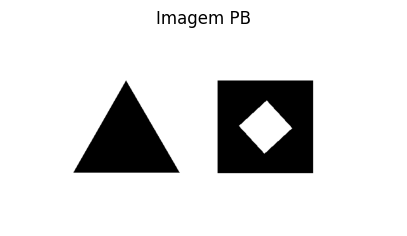

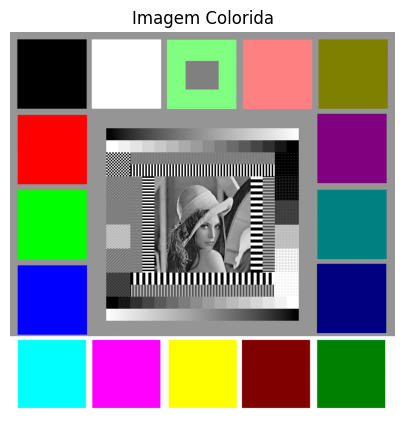

In [96]:
show_image(img_pb, title="Imagem PB")
show_image(img_color, title="Imagem Colorida")

In [97]:
#relu
params_generico_relu = "parametros_relu/generico.json"
params_gauss_relu = "parametros_relu/gaussiano5_5.json"
params_box_1_10_relu = "parametros_relu/box_1_10.json"
params_box_10_1_relu = "parametros_relu/box_10_1.json"
params_box_10_10_relu = "parametros_relu/box_10_10.json"
params_sobel_h_relu = "parametros_relu/sobel_h.json"
params_sobel_v_relu = "parametros_relu/sobel_v.json"

#identidade
params_generico_id = "parametros_id/generico.json"
params_gauss_id = "parametros_id/gaussiano5_5.json"
params_box_1_10_id = "parametros_id/box_1_10.json"
params_box_10_1_id = "parametros_id/box_10_1.json"
params_box_10_10_id = "parametros_id/box_10_10.json"
params_sobel_h_id = "parametros_id/sobel_h.json"
params_sobel_v_id = "parametros_id/sobel_v.json"

### Gaussiano 5x5 com ReLU

In [98]:
nome_filtro = os.path.splitext(os.path.basename(params_gauss_relu))[0]

stride, dilatacao, dims, filtro_gauss5_5, ativacao = ler_parametros_json(params_gauss_relu)
mostrar_parametros(stride, dilatacao, dims, filtro_gauss5_5, ativacao)

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [5, 5]
Filtro:
[[ 1  4  6  4  1]
 [ 4 16 24 16  4]
 [ 6 24 36 24  6]
 [ 4 16 24 16  4]
 [ 1  4  6  4  1]]
Ativação: relu


#### Imagem PB

Reescalando imagem final para evitar saturação (min=0.00, max=65280.00)


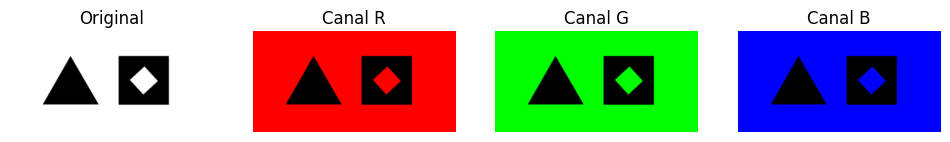

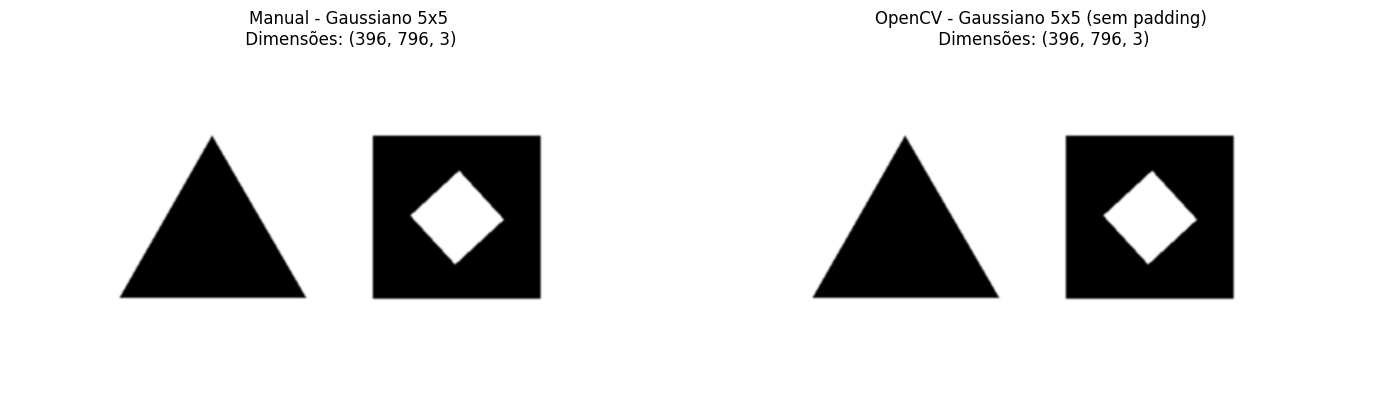

In [99]:
imagem_resultante = processar_imagem_rgb(r_pb, g_pb, b_pb, stride, dilatacao, filtro_gauss5_5, ativacao)

os.makedirs("resultados/pb_relu", exist_ok=True)
salvar_imagem(f"resultados/pb_relu/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_pb, filtro_gauss5_5)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Gaussiano 5x5")

#### Imagem Colorida

Reescalando imagem final para evitar saturação (min=0.00, max=65280.00)


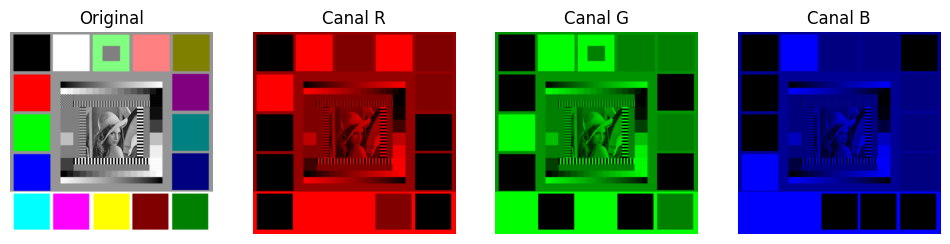

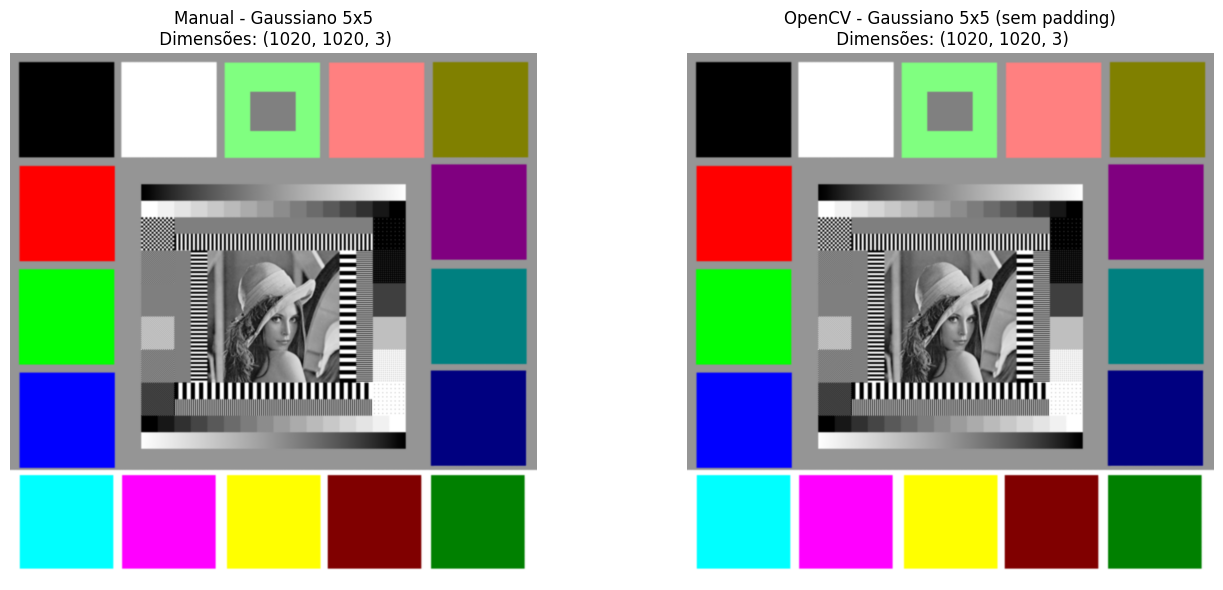

In [100]:
imagem_resultante = processar_imagem_rgb(r_color, g_color, b_color, stride, dilatacao, filtro_gauss5_5, ativacao)

os.makedirs("resultados/color_relu", exist_ok=True)
salvar_imagem(f"resultados/color_relu/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_color, filtro_gauss5_5)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Gaussiano 5x5")

### Gaussiano 5x5 com Identidade

In [101]:
nome_filtro = os.path.splitext(os.path.basename(params_gauss_id))[0]

stride, dilatacao, dims, filtro_gauss5_5, ativacao = ler_parametros_json(params_gauss_id)
mostrar_parametros(stride, dilatacao, dims, filtro_gauss5_5, ativacao)

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [5, 5]
Filtro:
[[ 1  4  6  4  1]
 [ 4 16 24 16  4]
 [ 6 24 36 24  6]
 [ 4 16 24 16  4]
 [ 1  4  6  4  1]]
Ativação: identidade


#### Imagem PB

Reescalando imagem final para evitar saturação (min=0.00, max=65280.00)


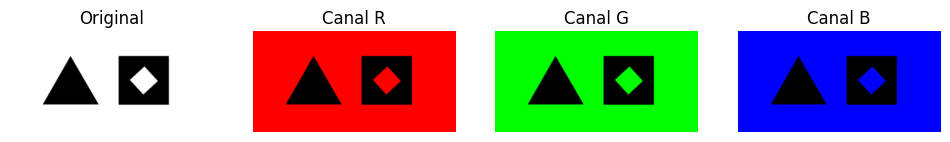

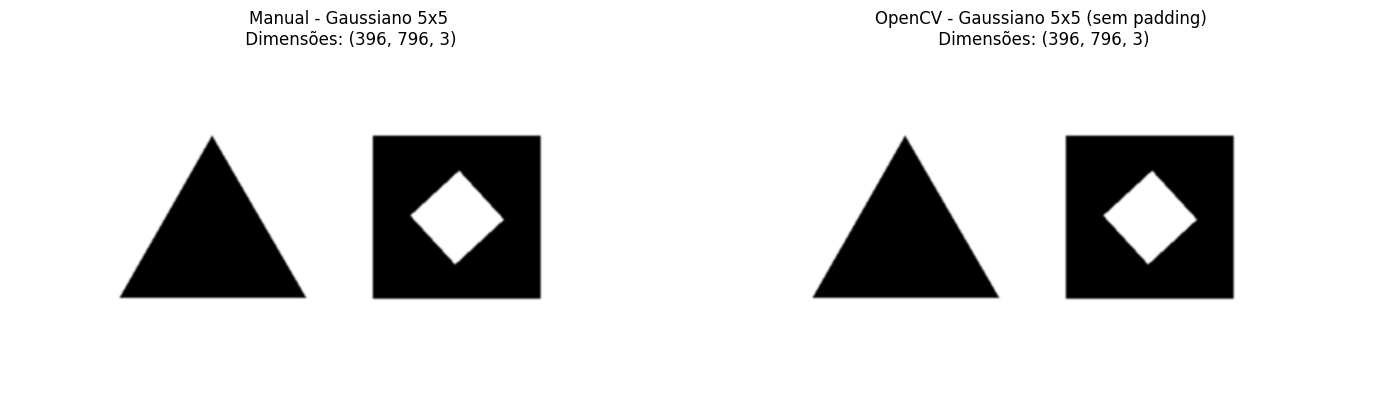

In [102]:
imagem_resultante = processar_imagem_rgb(r_pb, g_pb, b_pb, stride, dilatacao, filtro_gauss5_5, ativacao)

os.makedirs("resultados/pb_id", exist_ok=True)
salvar_imagem(f"resultados/pb_id/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_pb, filtro_gauss5_5)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Gaussiano 5x5")

#### Imagem Colorida

Reescalando imagem final para evitar saturação (min=0.00, max=65280.00)


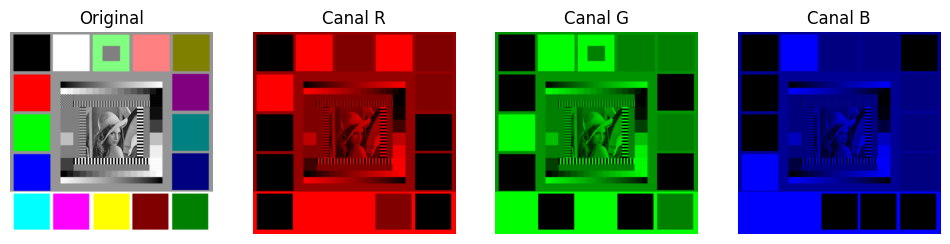

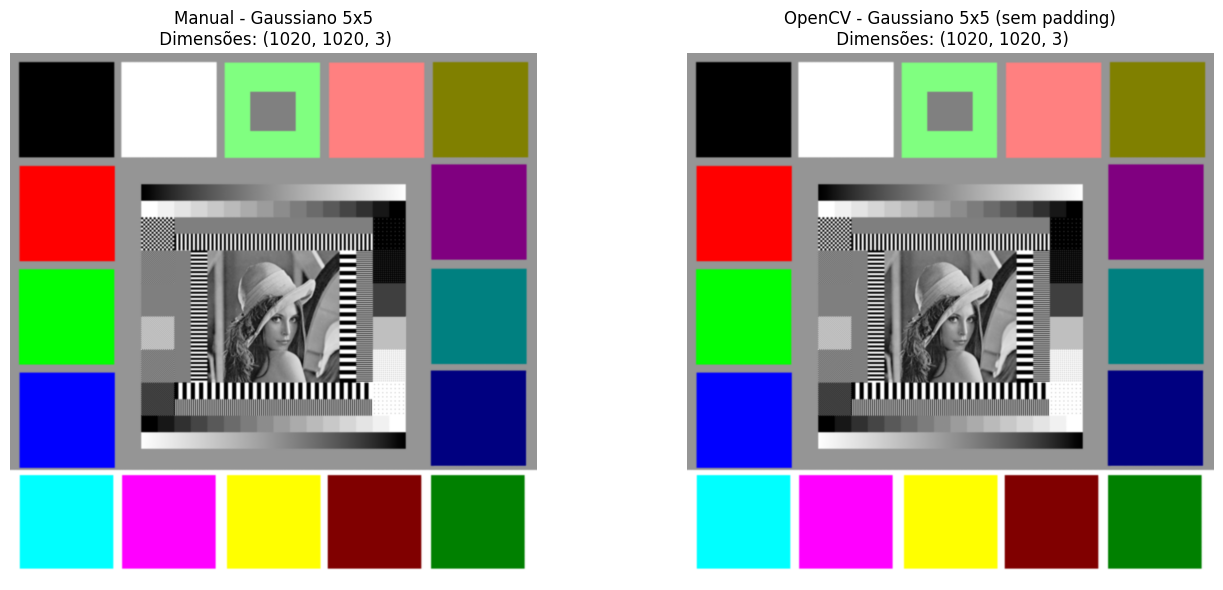

In [103]:
imagem_resultante = processar_imagem_rgb(r_color, g_color, b_color, stride, dilatacao, filtro_gauss5_5, ativacao)

os.makedirs("resultados/color_id", exist_ok=True)
salvar_imagem(f"resultados/color_id/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_color, filtro_gauss5_5)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Gaussiano 5x5")

### Box 1x10 com ReLU

#### Base

In [104]:
nome_filtro = os.path.splitext(os.path.basename(params_box_1_10_relu))[0]

stride, dilatacao, dims, filtro, ativacao = ler_parametros_json(params_box_1_10_relu)
mostrar_parametros(stride, dilatacao, dims, filtro, ativacao)

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [1, 10]
Filtro:
[[1 1 1 1 1 1 1 1 1 1]]
Ativação: relu


#### Imagem PB

Reescalando imagem final para evitar saturação (min=0.00, max=2550.00)


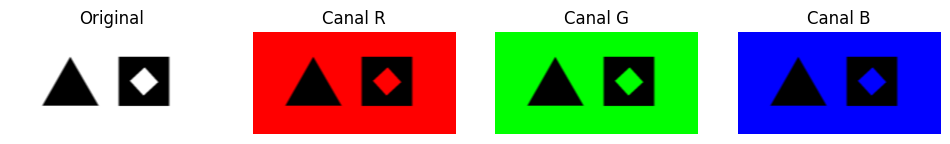

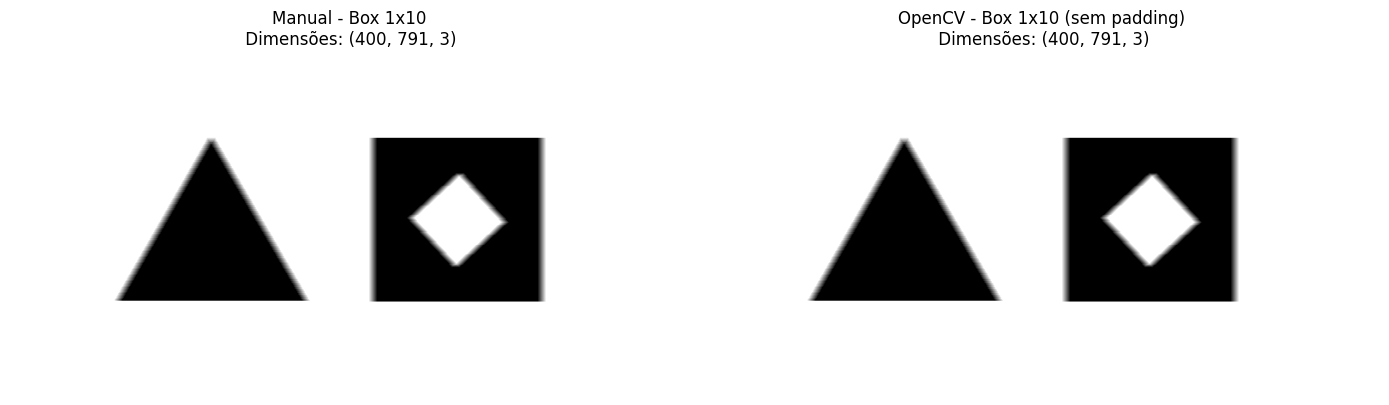

In [105]:
imagem_resultante = processar_imagem_rgb(r_pb, g_pb, b_pb, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/pb_relu", exist_ok=True)
salvar_imagem(f"resultados/pb_relu/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_pb, filtro)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Box 1x10")

#### Imagem colorida

Reescalando imagem final para evitar saturação (min=0.00, max=2550.00)


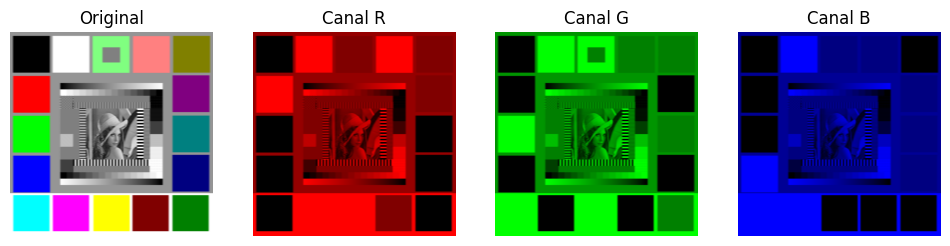

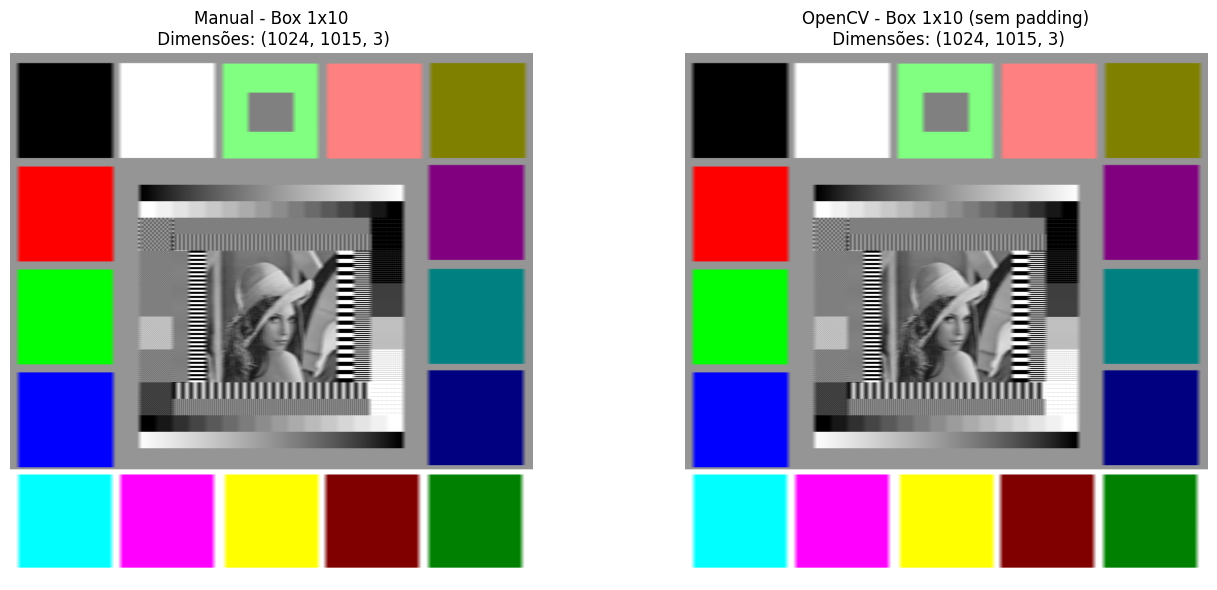

In [106]:
imagem_resultante = processar_imagem_rgb(r_color, g_color, b_color, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/color_relu", exist_ok=True)
salvar_imagem(f"resultados/color_relu/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_color, filtro)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Box 1x10")

### Box 1x10 com Identidade

#### Base

In [107]:
nome_filtro = os.path.splitext(os.path.basename(params_box_1_10_id))[0]

stride, dilatacao, dims, filtro, ativacao = ler_parametros_json(params_box_1_10_id)
mostrar_parametros(stride, dilatacao, dims, filtro, ativacao)

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [1, 10]
Filtro:
[[1 1 1 1 1 1 1 1 1 1]]
Ativação: identidade


#### Imagem PB

Reescalando imagem final para evitar saturação (min=0.00, max=2550.00)


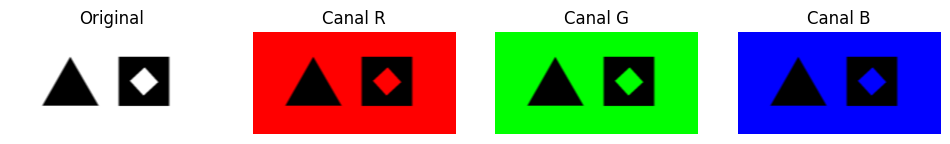

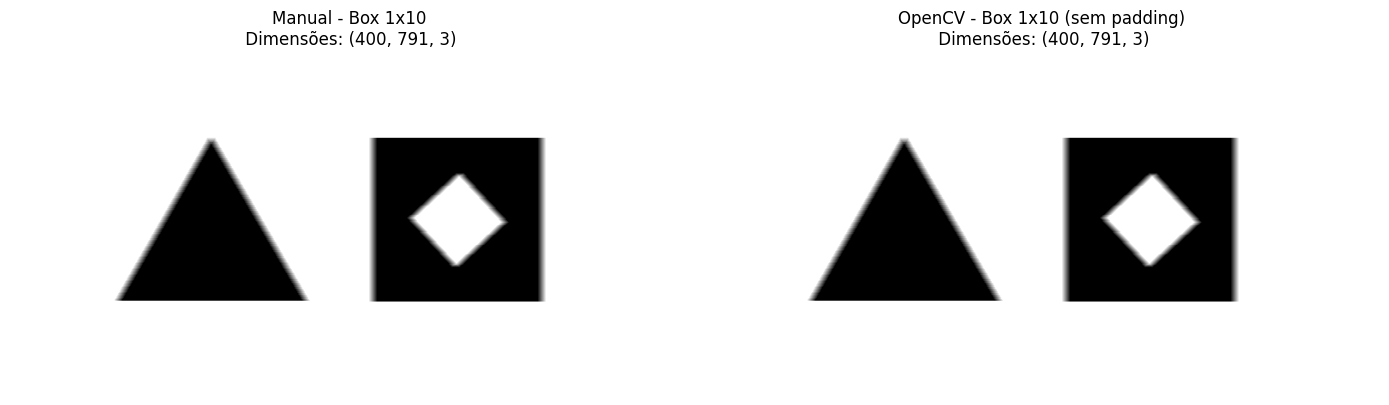

In [108]:
imagem_resultante = processar_imagem_rgb(r_pb, g_pb, b_pb, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/pb_id", exist_ok=True)
salvar_imagem(f"resultados/pb_id/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_pb, filtro)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Box 1x10")

#### Imagem colorida

Reescalando imagem final para evitar saturação (min=0.00, max=2550.00)


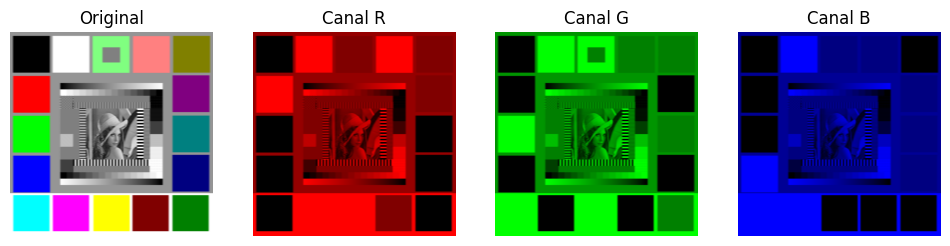

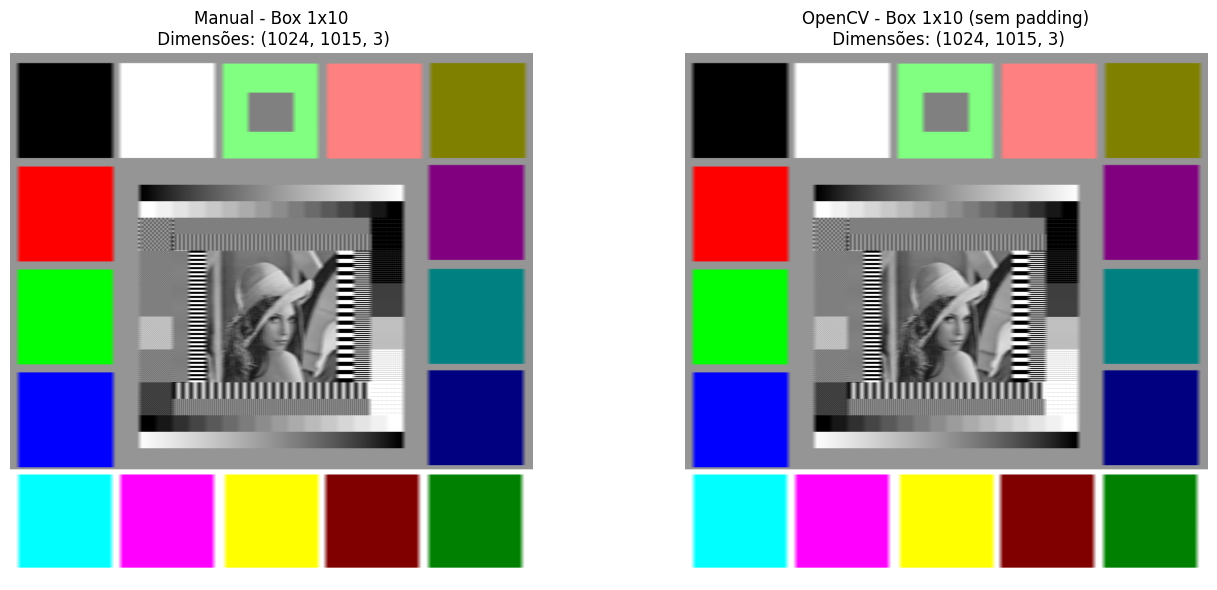

In [109]:
imagem_resultante = processar_imagem_rgb(r_color, g_color, b_color, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/color_id", exist_ok=True)
salvar_imagem(f"resultados/color_id/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_color, filtro)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Box 1x10")

### Box 10x1 com ReLU

#### Base

In [110]:
nome_filtro = os.path.splitext(os.path.basename(params_box_10_1_relu))[0]

stride, dilatacao, dims, filtro, ativacao = ler_parametros_json(params_box_10_1_relu)
mostrar_parametros(stride, dilatacao, dims, filtro, ativacao)

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [10, 1]
Filtro:
[[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]
Ativação: relu


#### Imagem PB

Reescalando imagem final para evitar saturação (min=0.00, max=2550.00)


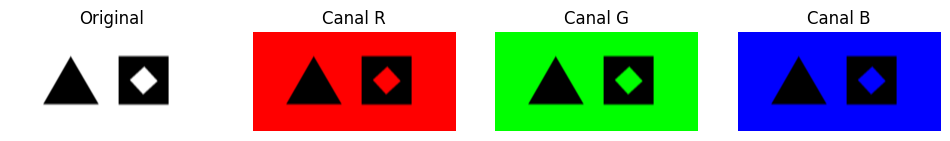

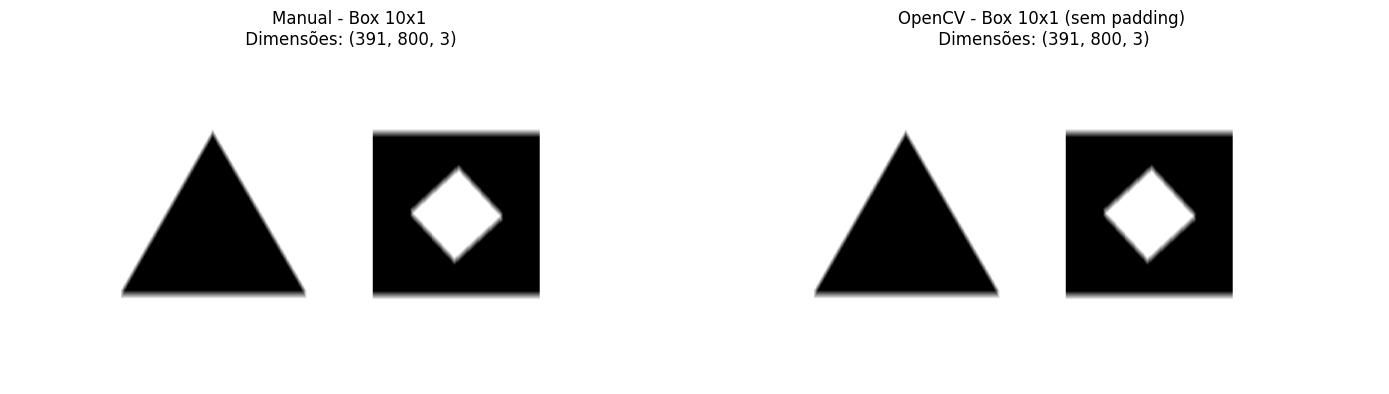

In [111]:
imagem_resultante = processar_imagem_rgb(r_pb, g_pb, b_pb, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/pb_relu", exist_ok=True)
salvar_imagem(f"resultados/pb_relu/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_pb, filtro)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Box 10x1")

##### Imagem colorida

Reescalando imagem final para evitar saturação (min=0.00, max=2550.00)


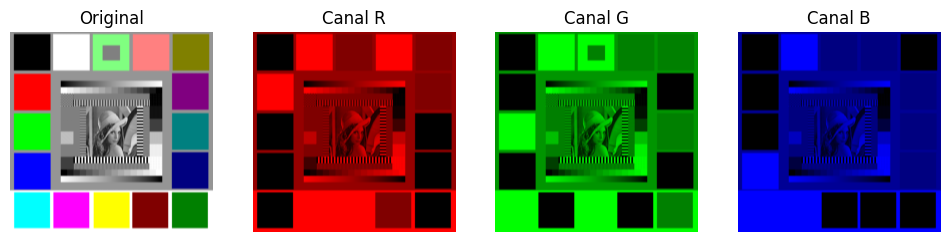

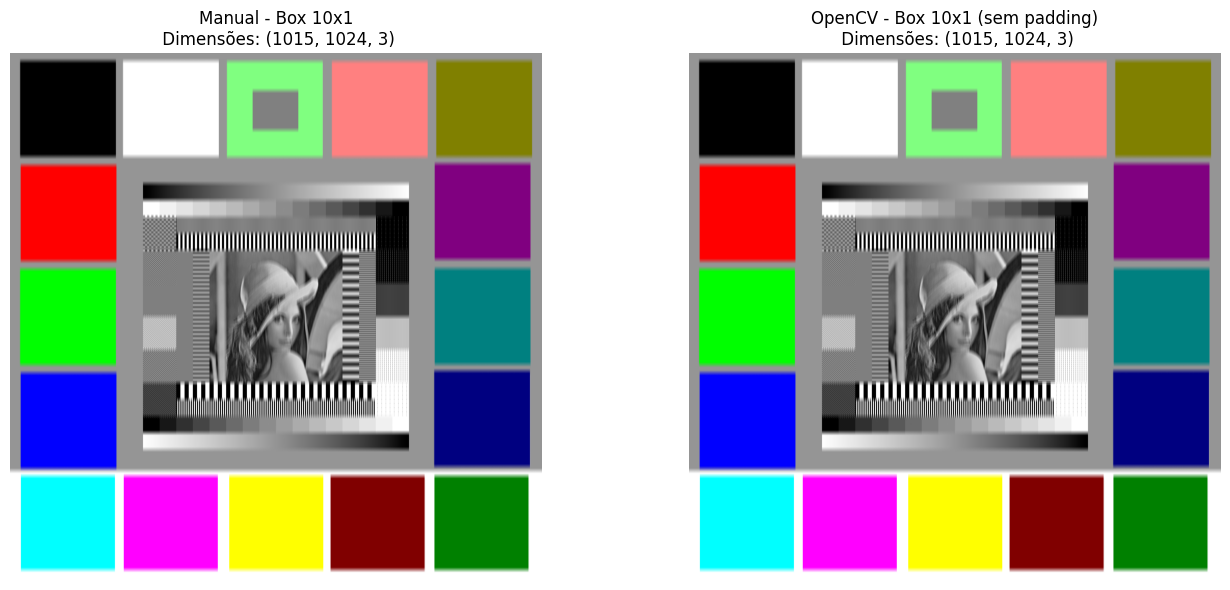

In [112]:
imagem_resultante = processar_imagem_rgb(r_color, g_color, b_color, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/color_relu", exist_ok=True)
salvar_imagem(f"resultados/color_relu/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_color, filtro)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Box 10x1")

### Box 10x1 com Identidade

#### Base

In [113]:
nome_filtro = os.path.splitext(os.path.basename(params_box_10_1_id))[0]

stride, dilatacao, dims, filtro, ativacao = ler_parametros_json(params_box_10_1_id)
mostrar_parametros(stride, dilatacao, dims, filtro, ativacao)

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [10, 1]
Filtro:
[[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]
Ativação: identidade


#### Imagem PB

Reescalando imagem final para evitar saturação (min=0.00, max=2550.00)


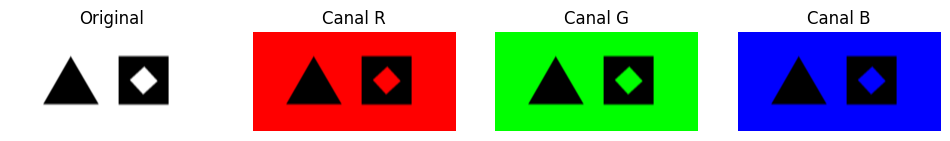

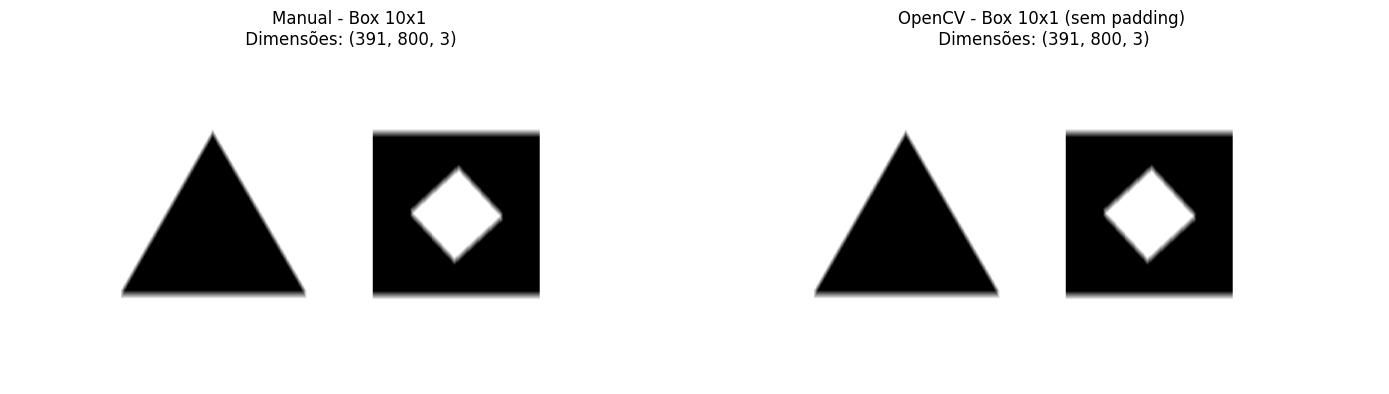

In [114]:
imagem_resultante = processar_imagem_rgb(r_pb, g_pb, b_pb, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/pb_id", exist_ok=True)
salvar_imagem(f"resultados/pb_id/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_pb, filtro)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Box 10x1")

##### Imagem colorida

Reescalando imagem final para evitar saturação (min=0.00, max=2550.00)


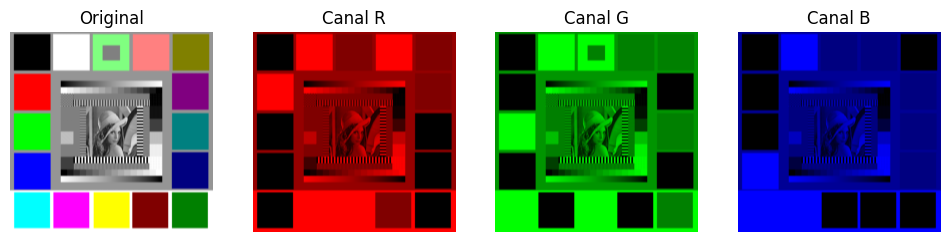

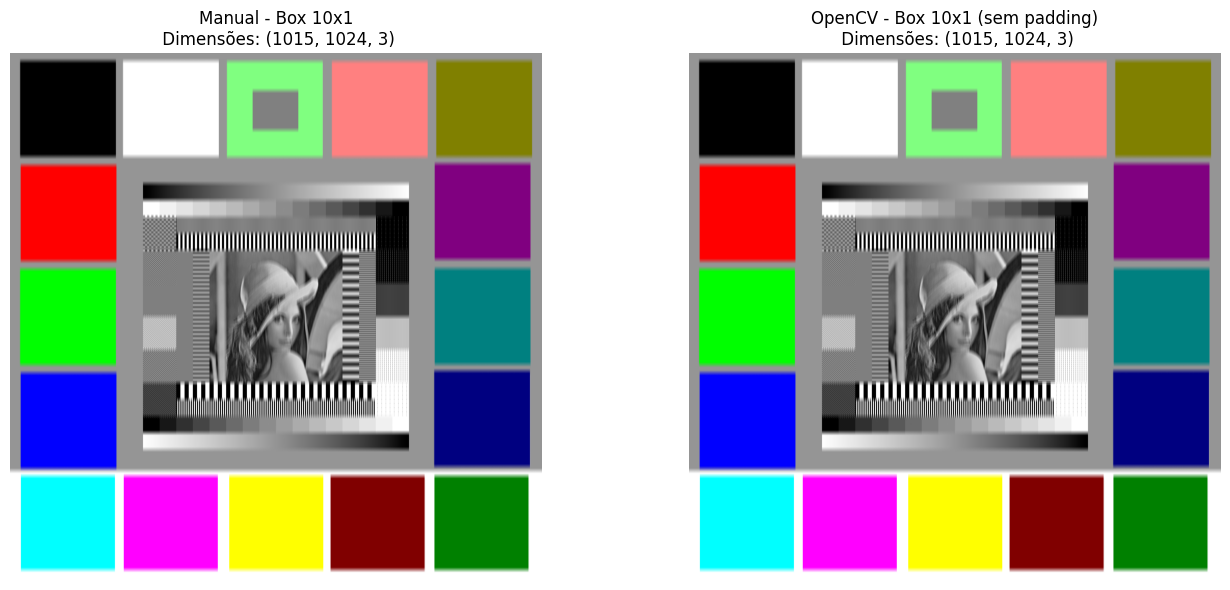

In [115]:
imagem_resultante = processar_imagem_rgb(r_color, g_color, b_color, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/color_id", exist_ok=True)
salvar_imagem(f"resultados/color_id/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_color, filtro)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Box 10x1")

### Box 10x10 com ReLU 

#### Base

In [116]:
nome_filtro = os.path.splitext(os.path.basename(params_box_10_10_relu))[0]

stride, dilatacao, dims, filtro, ativacao = ler_parametros_json(params_box_10_10_relu)
mostrar_parametros(stride, dilatacao, dims, filtro, ativacao)

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [10, 10]
Filtro:
[[1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]]
Ativação: relu


##### Imagem PB

Reescalando imagem final para evitar saturação (min=0.00, max=25500.00)


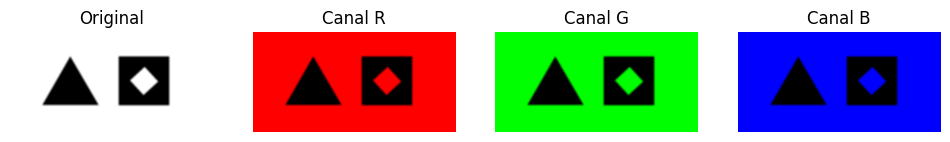

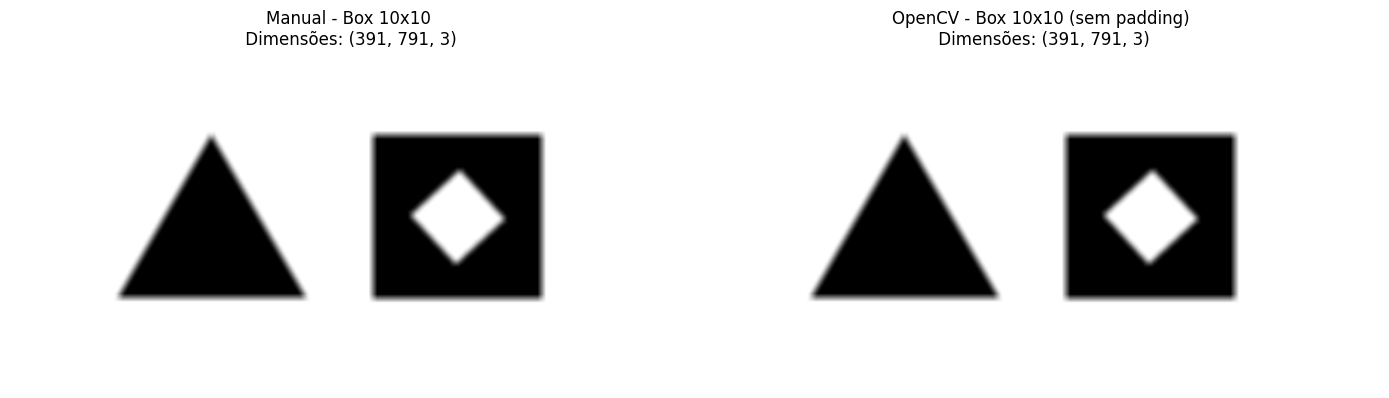

In [117]:
imagem_resultante = processar_imagem_rgb(r_pb, g_pb, b_pb, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/pb_relu", exist_ok=True)
salvar_imagem(f"resultados/pb_relu/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_pb, filtro)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Box 10x10")

#### Imagem colorida

Reescalando imagem final para evitar saturação (min=0.00, max=25500.00)


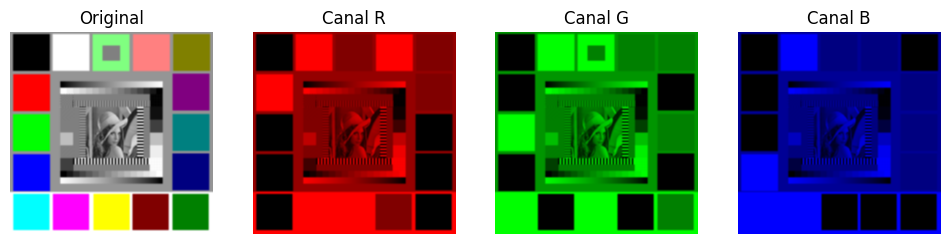

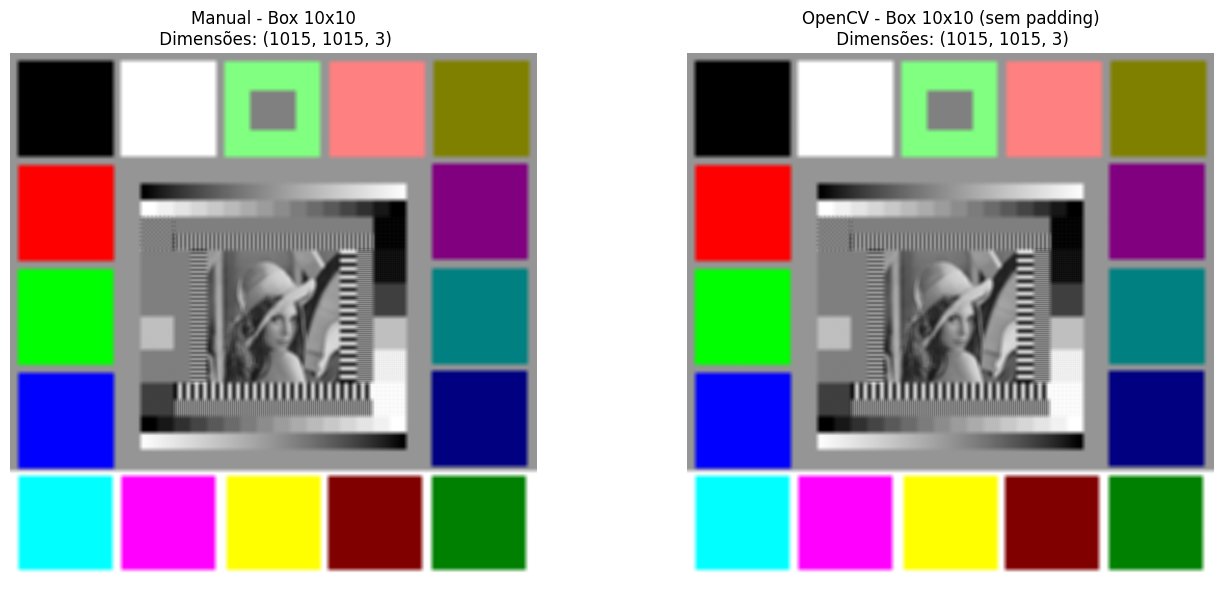

In [118]:
imagem_resultante = processar_imagem_rgb(r_color, g_color, b_color, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/color_relu", exist_ok=True)
salvar_imagem(f"resultados/color_relu/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_color, filtro)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Box 10x10")

### Box 10x10 com Identidade

#### Base

In [119]:
nome_filtro = os.path.splitext(os.path.basename(params_box_10_10_id))[0]

stride, dilatacao, dims, filtro, ativacao = ler_parametros_json(params_box_10_10_id)
mostrar_parametros(stride, dilatacao, dims, filtro, ativacao)

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [10, 10]
Filtro:
[[1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]]
Ativação: identidade


##### Imagem PB

Reescalando imagem final para evitar saturação (min=0.00, max=25500.00)


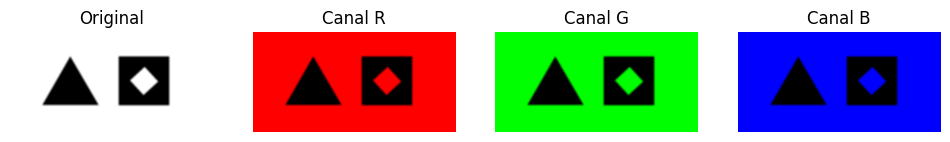

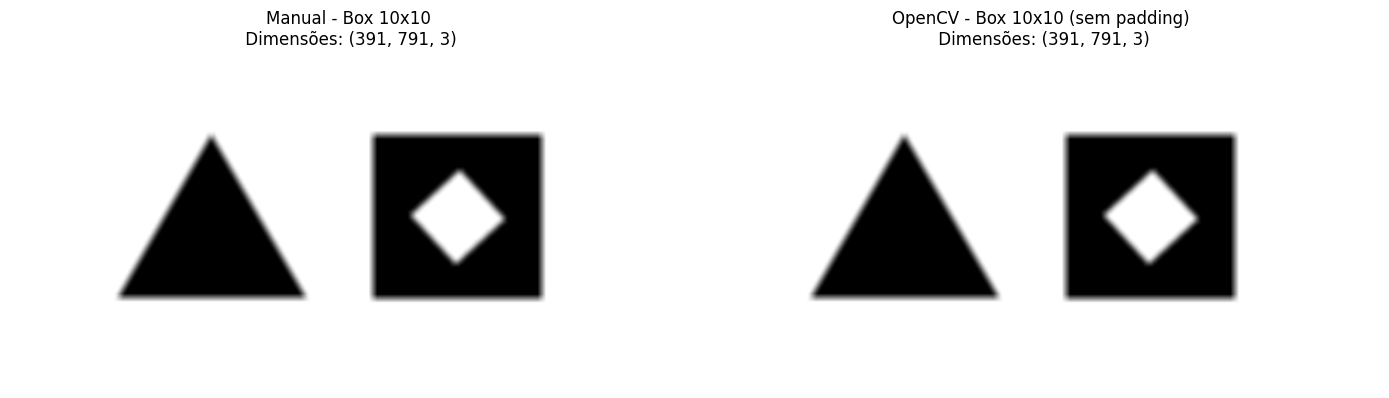

In [120]:
imagem_resultante = processar_imagem_rgb(r_pb, g_pb, b_pb, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/pb_id", exist_ok=True)
salvar_imagem(f"resultados/pb_id/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_pb, filtro)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Box 10x10")

#### Imagem colorida

Reescalando imagem final para evitar saturação (min=0.00, max=25500.00)


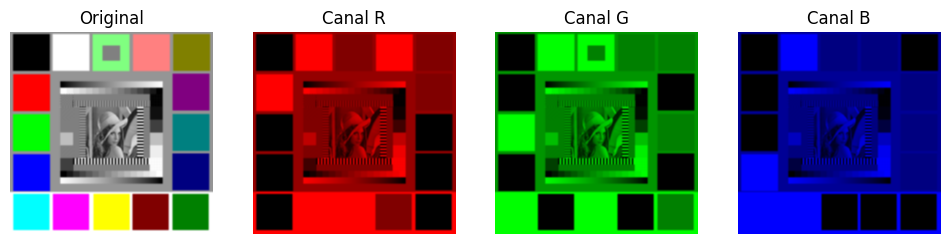

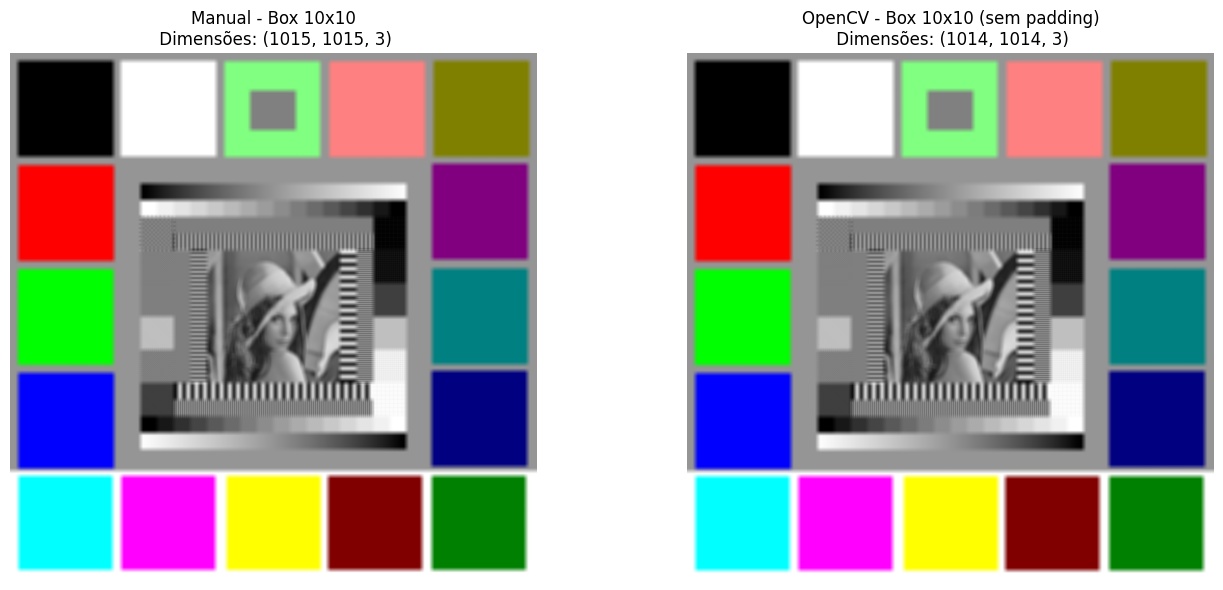

In [80]:
imagem_resultante = processar_imagem_rgb(r_color, g_color, b_color, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/color_id", exist_ok=True)
salvar_imagem(f"resultados/color_id/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_color, filtro)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Box 10x10")

### Sobel Horizontal com ReLU

#### Base

In [81]:
nome_filtro = os.path.splitext(os.path.basename(params_sobel_h_relu))[0]

stride, dilatacao, dims, filtro, ativacao = ler_parametros_json(params_sobel_h_relu)
mostrar_parametros(stride, dilatacao, dims, filtro, ativacao)

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [3, 3]
Filtro:
[[-1 -2 -1]
 [ 0  0  0]
 [ 1  2  1]]
Ativação: relu


#### Imagem PB

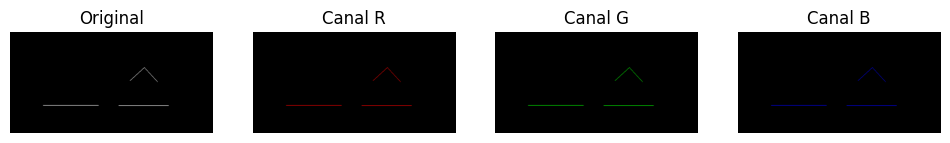

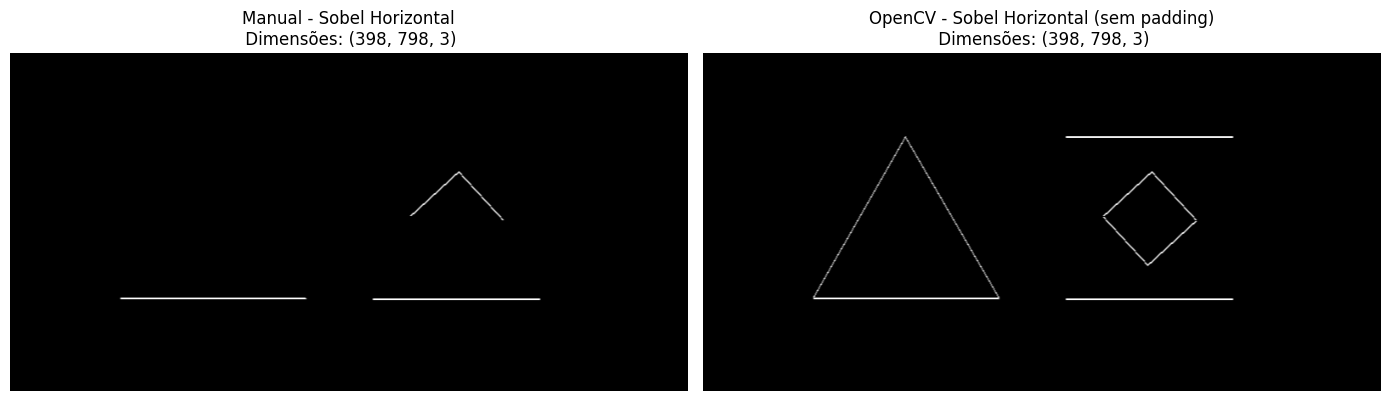

In [82]:
imagem_resultante = processar_imagem_rgb(r_pb, g_pb, b_pb, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/pb_relu", exist_ok=True)
salvar_imagem(f"resultados/pb_relu/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_pb, filtro)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Sobel Horizontal")

#### Imagem colorida

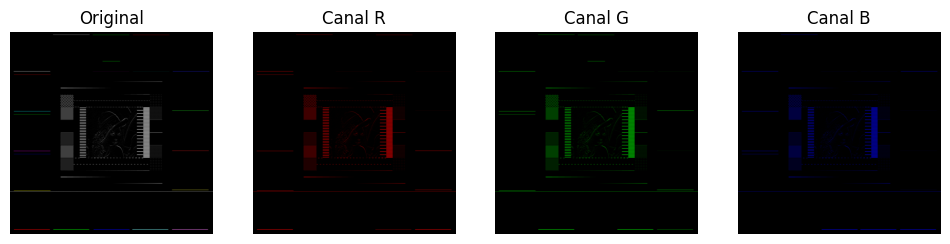

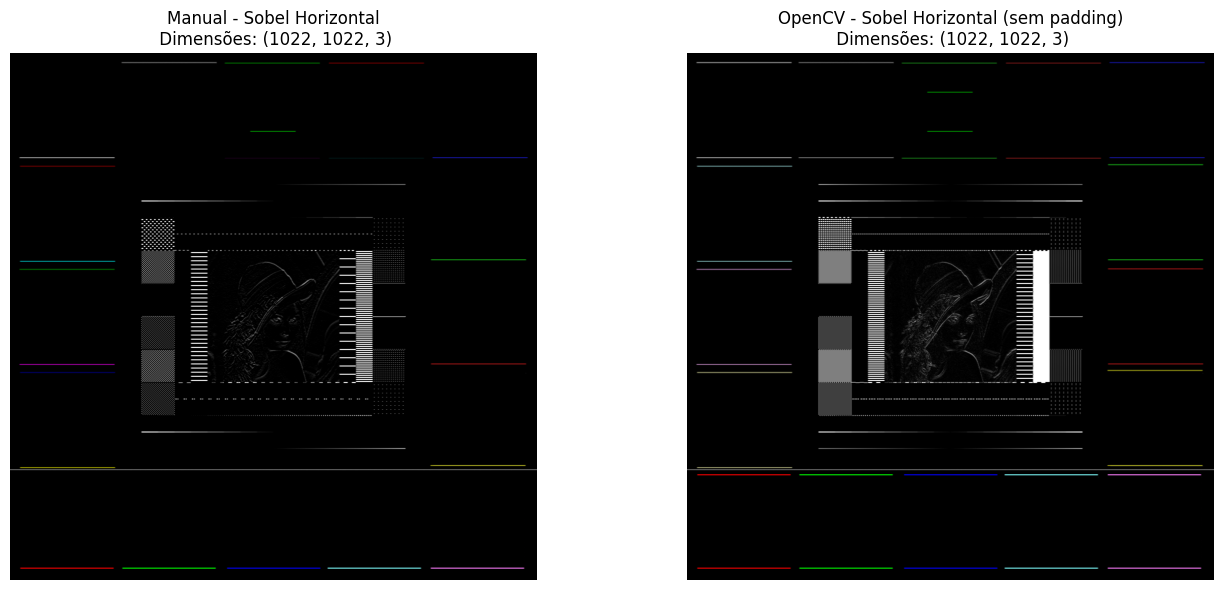

In [83]:
imagem_resultante = processar_imagem_rgb(r_color, g_color, b_color, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/color_relu", exist_ok=True)
salvar_imagem(f"resultados/color_relu/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_color, filtro)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Sobel Horizontal")

### Sobel Horizontal com Identidade

#### Base

In [84]:
nome_filtro = os.path.splitext(os.path.basename(params_sobel_h_id))[0]

stride, dilatacao, dims, filtro, ativacao = ler_parametros_json(params_sobel_h_id)
mostrar_parametros(stride, dilatacao, dims, filtro, ativacao)

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [3, 3]
Filtro:
[[-1 -2 -1]
 [ 0  0  0]
 [ 1  2  1]]
Ativação: identidade


#### Imagem PB

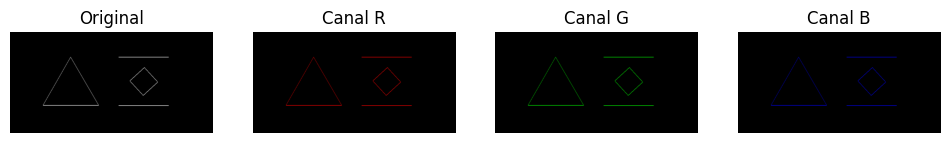

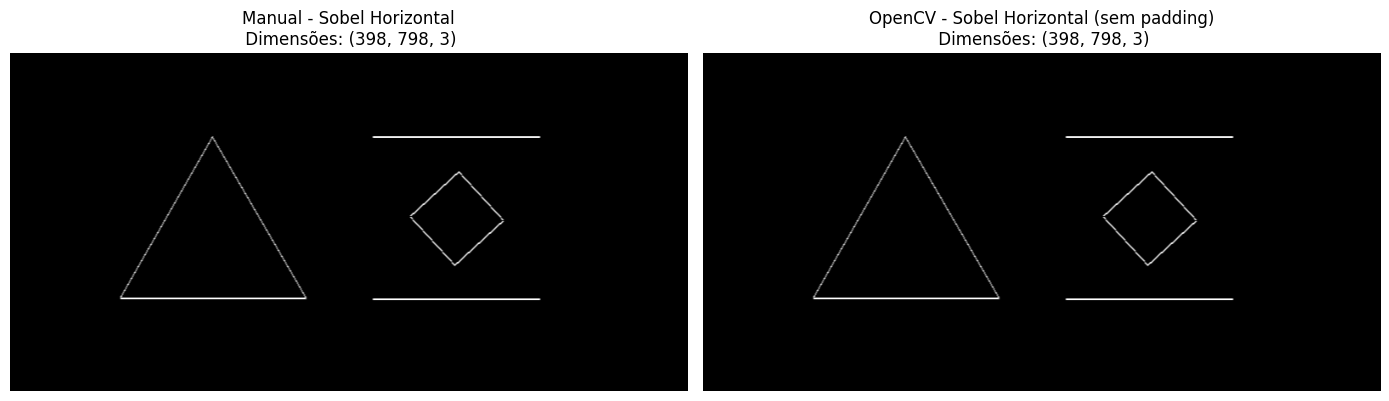

In [85]:
imagem_resultante = processar_imagem_rgb(r_pb, g_pb, b_pb, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/pb_id", exist_ok=True)
salvar_imagem(f"resultados/pb_id/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_pb, filtro)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Sobel Horizontal")

#### Imagem colorida

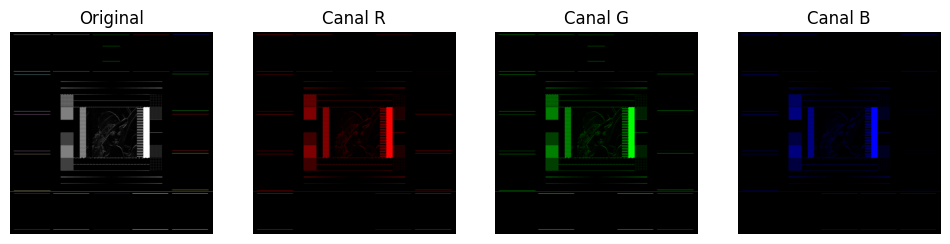

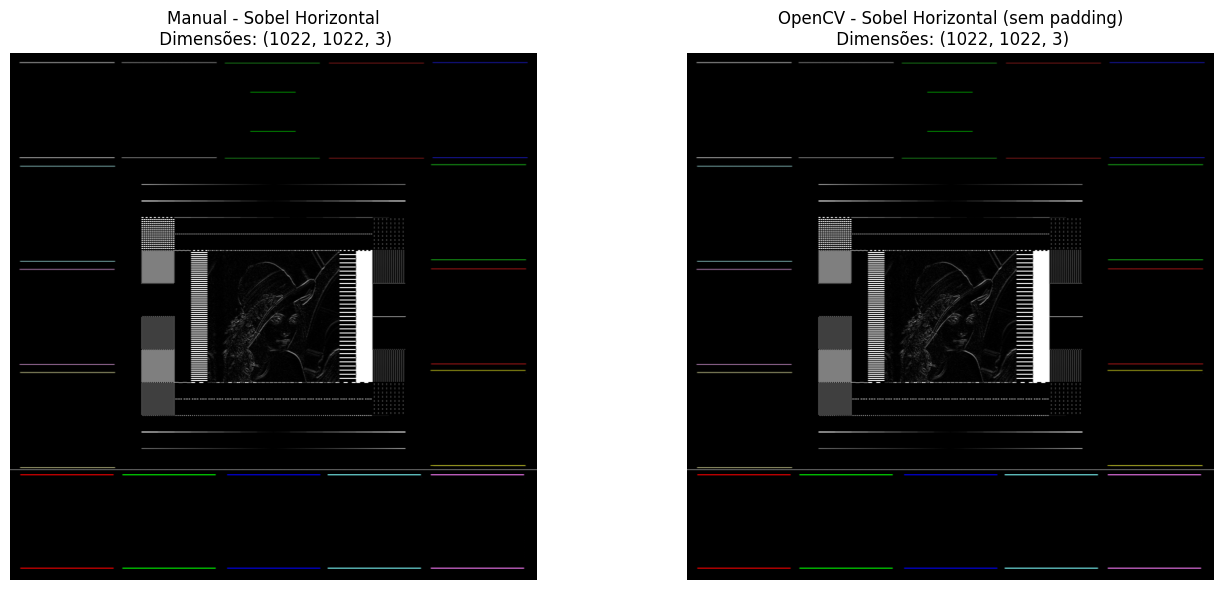

In [86]:
imagem_resultante = processar_imagem_rgb(r_color, g_color, b_color, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/color_id", exist_ok=True)
salvar_imagem(f"resultados/color_id/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_color, filtro)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Sobel Horizontal")

### Sobel Vertical com ReLU

#### Base

In [87]:
nome_filtro = os.path.splitext(os.path.basename(params_sobel_v_relu))[0]

stride, dilatacao, dims, filtro, ativacao = ler_parametros_json(params_sobel_v_relu)
mostrar_parametros(stride, dilatacao, dims, filtro, ativacao)

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [3, 3]
Filtro:
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]
Ativação: relu


#### Imagem PB

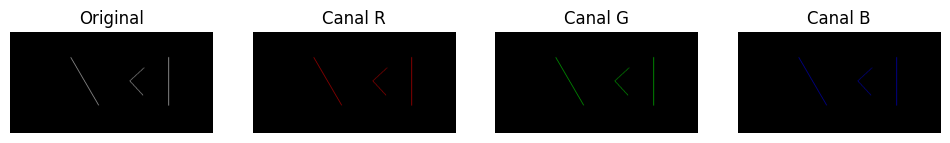

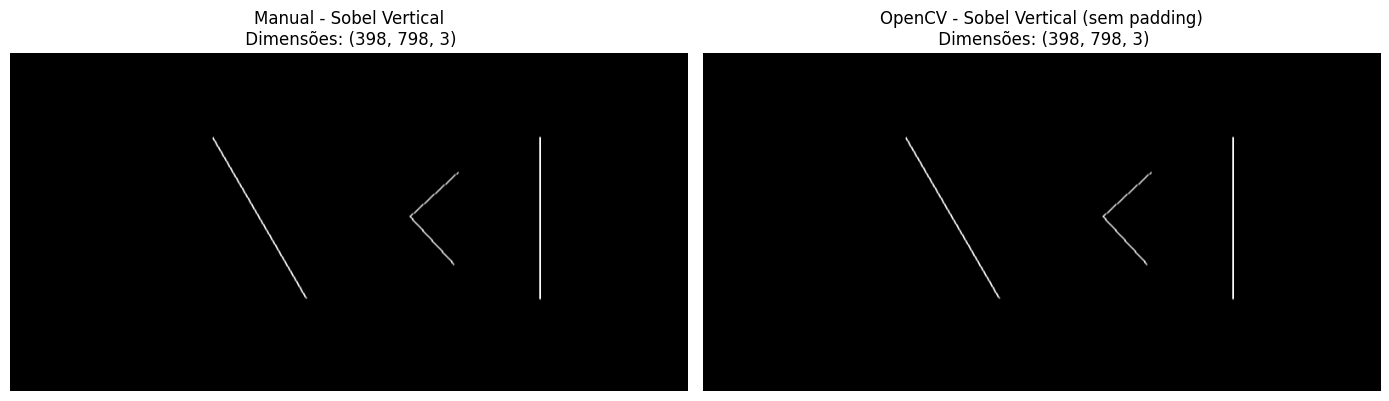

In [88]:
imagem_resultante = processar_imagem_rgb(r_pb, g_pb, b_pb, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/pb_relu", exist_ok=True)
salvar_imagem(f"resultados/pb_relu/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_pb, filtro, ativacao)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Sobel Vertical")

#### Imagem colorida

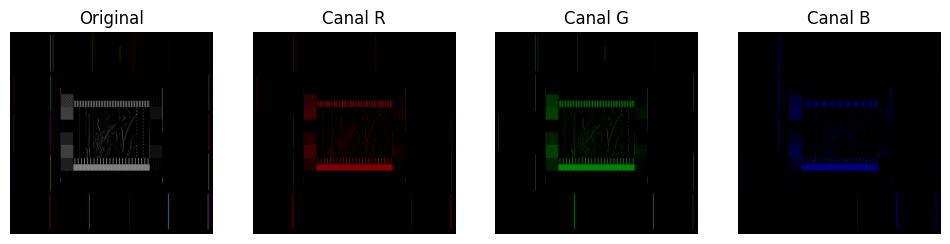

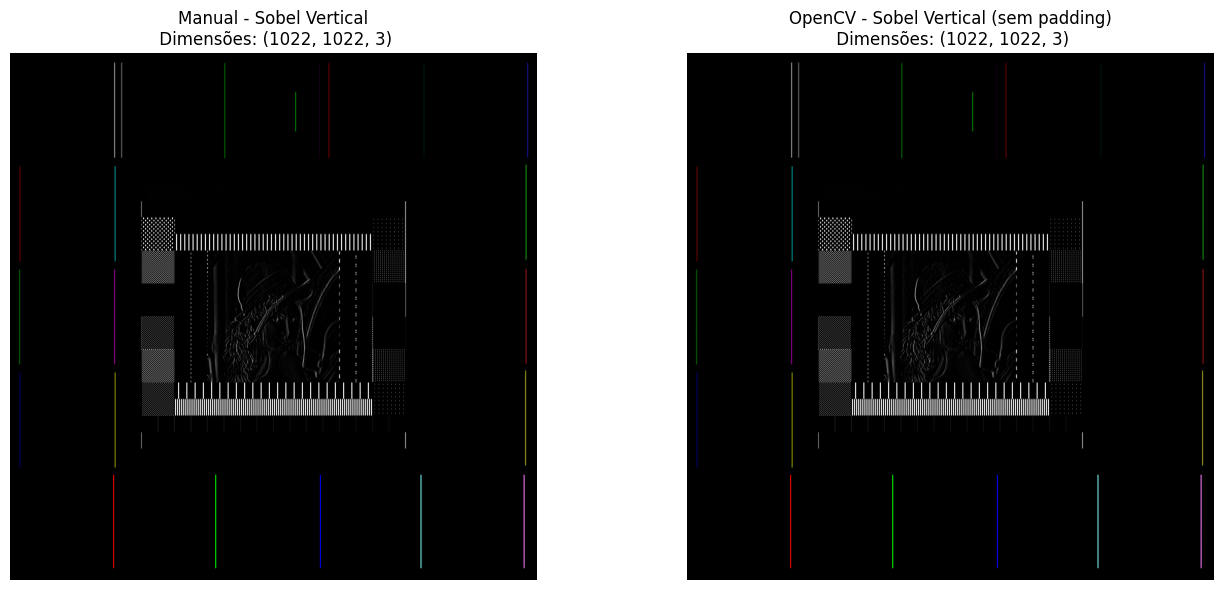

In [89]:
imagem_resultante = processar_imagem_rgb(r_color, g_color, b_color, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/color_relu", exist_ok=True)
salvar_imagem(f"resultados/color_relu/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_color, filtro, ativacao)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Sobel Vertical")

### Sobel Vertical com Identidade

#### Base

In [90]:
nome_filtro = os.path.splitext(os.path.basename(params_sobel_v_id))[0]

stride, dilatacao, dims, filtro, ativacao = ler_parametros_json(params_sobel_v_id)
mostrar_parametros(stride, dilatacao, dims, filtro, ativacao)

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [3, 3]
Filtro:
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]
Ativação: identidade


#### Imagem PB

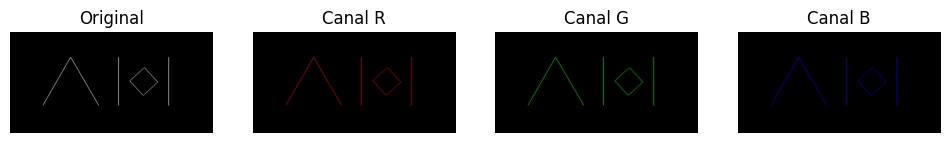

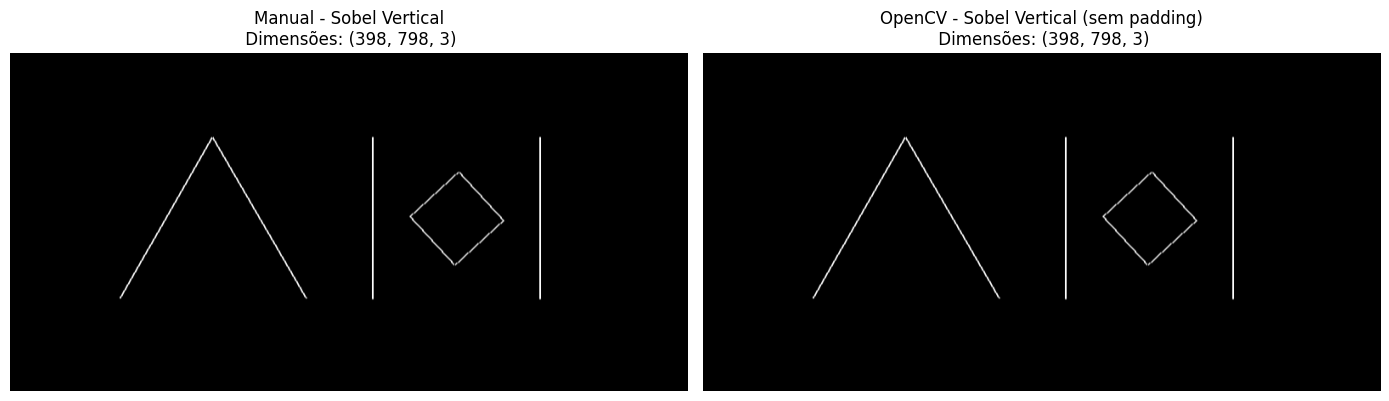

In [91]:
imagem_resultante = processar_imagem_rgb(r_pb, g_pb, b_pb, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/pb_id", exist_ok=True)
salvar_imagem(f"resultados/pb_id/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_pb, filtro, ativacao)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Sobel Vertical")

#### Imagem colorida

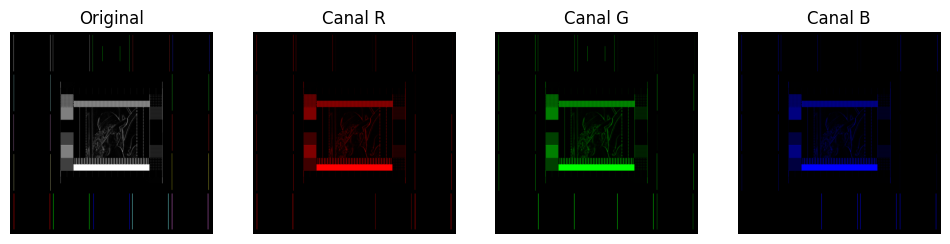

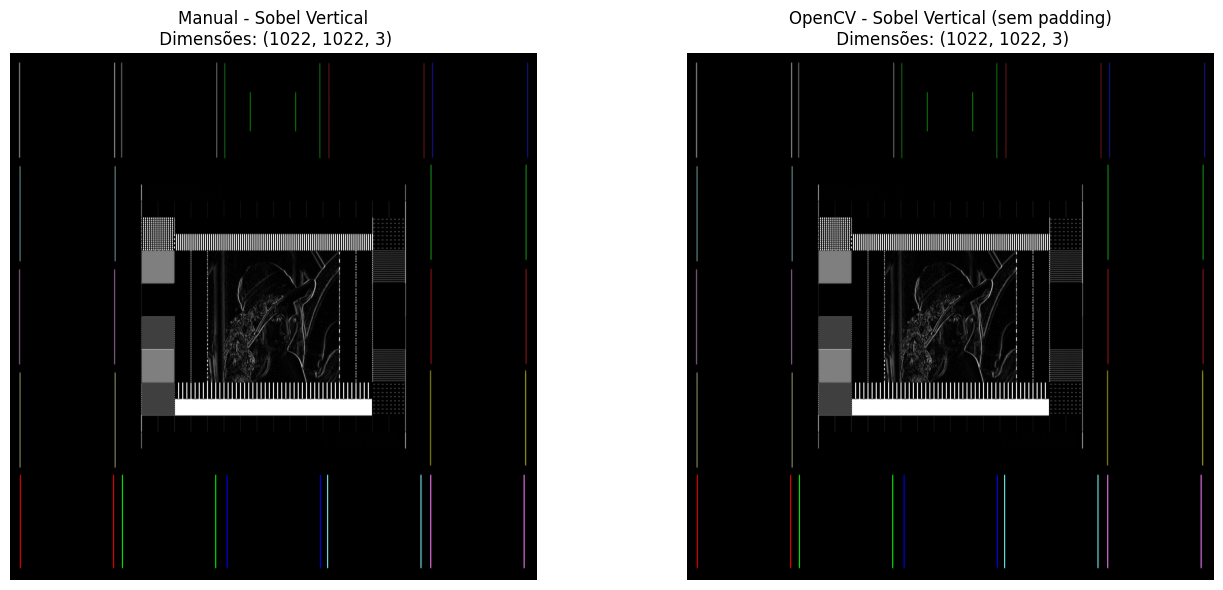

In [92]:
imagem_resultante = processar_imagem_rgb(r_color, g_color, b_color, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados/color_id", exist_ok=True)
salvar_imagem(f"resultados/color_id/{nome_filtro}_manual.jpg", imagem_resultante)

imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img_color, filtro, ativacao)
visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Sobel Vertical")